In [4]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd

all_years = pd.read_csv('./data/site_species_presence.csv')

all_years = all_years[['Unique_ID', 'latitude', 'longitude', 'watershed_area', 'cw_ind', 'pct_dev']]


all_3 = all_years[all_years['pct_dev'] <= 3]
all_5 = all_years[all_years['pct_dev'] <= 5]
all_7 = all_years[all_years['pct_dev'] <= 7]
all_10 = all_years[all_years['pct_dev'] <= 10]
all_15 = all_years[all_years['pct_dev'] <= 15]

In [5]:
import sys
sys.path.append('./utils')
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV

datasets = [
    ('pct_dev <= 3%',  all_3,  0.25),
    ('pct_dev <= 5%',  all_5,  0.25),
    ('pct_dev <= 7%',  all_7,  0.25),
    ('pct_dev <= 10%', all_10, 0.25),
    ('pct_dev <= 15%', all_15, 0.25),
]

best_k = {}

for name, df, _ in datasets:
    feature_cols = [c for c in df.columns if c not in ['Unique_ID', 'cw_ind', 'pct_dev']]
    X = df[feature_cols].values
    y = df['cw_ind'].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    grid = GridSearchCV(
        KNeighborsClassifier(),
        param_grid={'n_neighbors': range(3, 21, 2)},
        scoring='roc_auc',
        cv=cv,
    )
    grid.fit(X_scaled, y)
    best_k[name] = grid.best_params_['n_neighbors']
    print(f"{name}: best k={grid.best_params_['n_neighbors']}  (AUC={grid.best_score_:.4f})")


pct_dev <= 3%: best k=19  (AUC=0.7284)
pct_dev <= 5%: best k=19  (AUC=0.7982)
pct_dev <= 7%: best k=15  (AUC=0.7922)
pct_dev <= 10%: best k=9  (AUC=0.7884)
pct_dev <= 15%: best k=13  (AUC=0.8148)


Accuracy: 0.87
Precision: 0.87
Recall: 1.00
F1 Score: 0.93


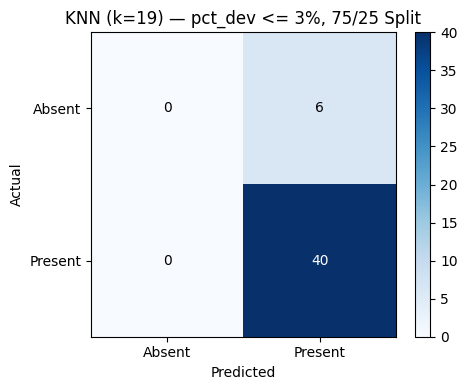

Accuracy: 0.88
Precision: 0.87
Recall: 1.00
F1 Score: 0.93


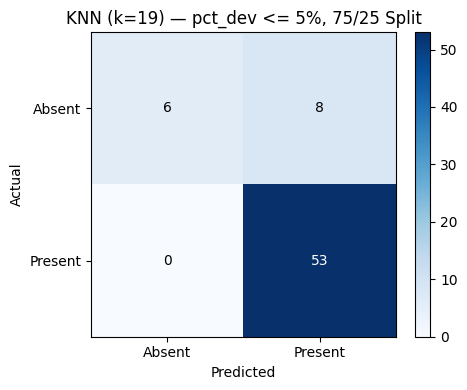

Accuracy: 0.75
Precision: 0.80
Recall: 0.90
F1 Score: 0.85


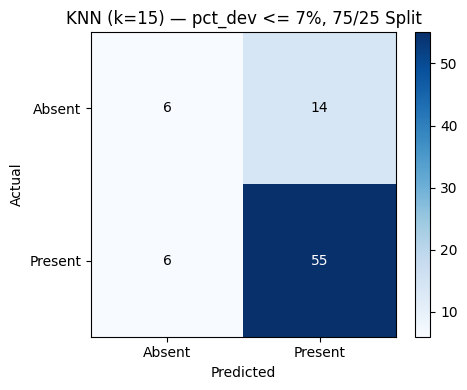

Accuracy: 0.74
Precision: 0.80
Recall: 0.86
F1 Score: 0.83


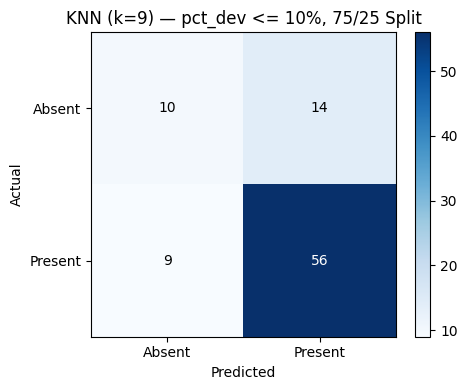

Accuracy: 0.78
Precision: 0.84
Recall: 0.85
F1 Score: 0.85


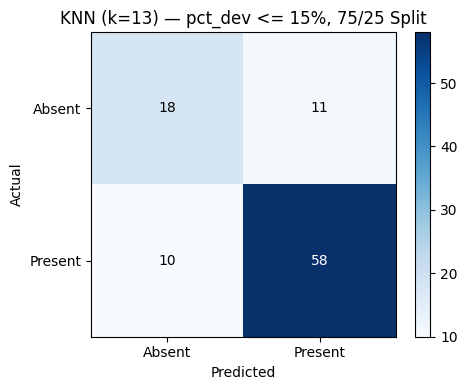

In [6]:
from utils.confusion import classification_report_suite

for name, df, test_size in datasets:
    feature_cols = [c for c in df.columns if c not in ['Unique_ID', 'cw_ind', 'pct_dev']]
    X = df[feature_cols].values
    y = df['cw_ind'].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    k = best_k[name]
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)

    classification_report_suite(
        y_test, y_pred,
        labels=['Absent', 'Present'],
        title=f'KNN (k={k}) — {name}, {int((1-test_size)*100)}/{int(test_size*100)} Split'
    )
